# Final Results: Adult Rest/Movie

> **Reproducibility note (read before running):** this notebook is one of a set of
> `0*_*.ipynb` notebooks split out of the original `compiled_results_analysis.ipynb`
> for the publication reproducibility bundle, meant to be run with the repo root (`task_dim/`) as
> the working directory. Each notebook is self-contained (re-loads its own
> inputs rather than relying on variables from other notebooks). A global `SEED = 4` is set at
> the top of the setup cell so every resampling/permutation step below is deterministic.
>
> **Inputs used here are pre-computed.** Where a cell loads a CSV/NIfTI file, a comment states
> which upstream script produced it. A few inputs this notebook depends on
> (`compiled/info/combined_participant_info.csv`, `compiled/results/*_compiled_results.csv`,
> `compiled/results/combined_corrs.csv`, `compiled/results/combined_corr_analyses.csv`) 

In [8]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from nilearn import image
from nilearn.maskers import NiftiMasker
from matplotlib.colors import ListedColormap
from matplotlib import rcParams
import plotting_helpers as helper          # surface plots, colormaps, dataset colors
import stats_helpers as stats_helpers      # permutation tests, (parcelwise/LME) regression, FDR correction
from scipy.stats import ttest_rel

rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

PLOT_DIR = 'compiled/plots'
os.makedirs(PLOT_DIR, exist_ok=True)
ISC_CMAP = 'OrRd'
ID_CMAP = helper.custom_blues_cmap()
dataset_colors = helper.dataset_colors('all')

# Global seed: makes every unseeded resample/permutation call below reproducible.
SEED = 4
np.random.seed(SEED)

## Load average ISC/IDE volumes (aeronaut, mickey, rest)

In [4]:
# INPUT: adult_restmovie/results/{task}_{measure}_all_subjects_results.nii.gz
#   Stacked per-subject volumes. Produced by searchlight_IDE_methods.py (IDE) /
#   searchlight_isc.py (ISC), then stacked by aggregate_results_volumes.py.
results_dir_arm = './adult_restmovie/results'
tasks_arm = ['aeronaut', 'rest']
measures_arm = {'ISC': 'ISC', 'TPHATE_DiffOp_IDE': 'IDE'}
avg_results_arm = {}
for task in tasks_arm:
    avg_results_arm[task] = {}
    for measure in measures_arm.keys():
        fn = f'{results_dir_arm}/{task}_{measure}_all_subjects_results.nii.gz'
        if os.path.exists(fn):
            nii = nib.load(fn)
            avg = image.mean_img(nii)
            print(f"Loaded {task} {measure}: shape {avg.shape}")
            avg_results_arm[task][measure] = avg
        else:
            print(f"Warning: {fn} not found")

/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61372/2410931487.py:14: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  avg = image.mean_img(nii)


Loaded aeronaut ISC: shape (60, 72, 60)
Loaded aeronaut TPHATE_DiffOp_IDE: shape (60, 72, 60)
Loaded rest ISC: shape (60, 72, 60)
Loaded rest TPHATE_DiffOp_IDE: shape (60, 72, 60)


## Surface plots: aeronaut/rest ISC and IDE

In [5]:
helper.generate_surface_plot(
    data_fn=avg_results_arm['aeronaut']['TPHATE_DiffOp_IDE'],
    image_fn=f'{PLOT_DIR}/adult_restmovie_aeronaut_ide_surface.pdf',
    atlas='searchlight', cmap=ID_CMAP, cbar_range=(1, 18),
    surf_type='fslr', target_density='32k', include_cbar=True,
    title='Aeronaut IDE', method='linear', threshold=None, mask_medial_wall=True
)

helper.generate_surface_plot(
    data_fn=avg_results_arm['aeronaut']['ISC'],
    image_fn=f'{PLOT_DIR}/adult_restmovie_aeronaut_isc_surface.pdf',
    atlas='searchlight', cmap=ISC_CMAP, cbar_range=(0, 0.4),
    surf_type='fslr', target_density='32k', include_cbar=True,
    title='Aeronaut ISC', method='linear', threshold=None, mask_medial_wall=True
)

helper.generate_surface_plot(
    data_fn=avg_results_arm['rest']['TPHATE_DiffOp_IDE'],
    image_fn=f'{PLOT_DIR}/adult_restmovie_rest_ide_surface.pdf',
    atlas='searchlight', cmap=ID_CMAP, cbar_range=(1, 25),
    surf_type='fslr', target_density='32k', include_cbar=True,
    title='Rest IDE', method='linear', threshold=None, mask_medial_wall=True
)

Generated surface plot: compiled/plots/adult_restmovie_aeronaut_ide_surface.pdf
Generated surface plot: compiled/plots/adult_restmovie_aeronaut_isc_surface.pdf
Generated surface plot: compiled/plots/adult_restmovie_rest_ide_surface.pdf


('compiled/plots/adult_restmovie_rest_ide_surface.pdf',
 <nibabel.nifti1.Nifti1Image at 0x310d98490>)

## Aeronaut-Rest difference maps

In [6]:
# INPUT: adult_restmovie/results/aeronaut_rest_TPHATE_DiffOp_IDE_SL_difference_maps_avg_{suffix}.nii.gz
#   Produced by aggregate_results_volumes.py.
diff_maps_dir = f'{results_dir_arm}/'
diff_results_arm = {}
pair = 'aeronaut_rest'
diff_results_arm[pair] = {}
for kind, suffix in [('thresholded', 'thresholded'), ('unthresholded', 'unthresholded')]:
    fn = f'{diff_maps_dir}/{pair}_TPHATE_DiffOp_IDE_SL_difference_maps_avg_{suffix}.nii.gz'
    if os.path.exists(fn):
        diff_results_arm[pair][kind] = nib.load(fn)
        helper.generate_surface_plot(
            data_fn=diff_results_arm[pair][kind],
            image_fn=f'{PLOT_DIR}/adult_restmovie_rest_aeronaut_surface.pdf',
            atlas='searchlight', cmap=helper.diverging_colormap_bp(), cbar_range=(-9, 9),
            surf_type='fslr', target_density='32k', include_cbar=True,
            title='Rest IDE', method='linear', threshold=None, mask_medial_wall=True
            )
        print(f"Loaded {pair} {kind}")
    else:
        print(f"Warning: {fn} not found")

Generated surface plot: compiled/plots/adult_restmovie_rest_aeronaut_surface.pdf
Loaded aeronaut_rest thresholded
Generated surface plot: compiled/plots/adult_restmovie_rest_aeronaut_surface.pdf
Loaded aeronaut_rest unthresholded


## Mean IDE barplot by task (aeronaut, rest)

Loaded aeronaut: 11 subjects, mean IDE across subjects = 11.464, sd = 2.978
Loaded rest: 11 subjects, mean IDE across subjects = 16.569, sd = 4.759


/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61372/426677470.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ide_df_arm, x='task', y='mean_IDE', palette=cmap_arm, edgecolor='k', linewidth=2, alpha=0.6)
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61372/426677470.py:27: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=ide_df_arm, x='task', y='mean_IDE', palette=cmap_arm, edgecolor='k', linewidth=2, alpha=0.6)
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61372/426677470.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=ide_df_arm, x='task', y='mean_IDE', palette=cmap_

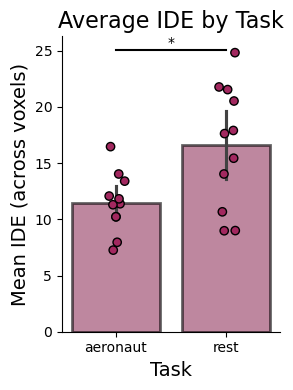

In [13]:
# INPUT: adult_restmovie/masks/adult_restmovie_intersect_mask.nii.gz
#   Group intersection mask; produced by create_intersect_mask_file_lists.py +
#   adult_restmovie_config.py / adult_restmovie_utils.py.
ide_subject_averages_arm = []
mask = nib.load('adult_restmovie/masks/adult_restmovie_intersect_mask.nii.gz')
masker = NiftiMasker(mask_img=mask)
for task in ['aeronaut', 'rest']:
    ide_fn = f'{results_dir_arm}/{task}_TPHATE_DiffOp_IDE_all_subjects_results.nii.gz'
    if os.path.exists(ide_fn):
        ide_img = nib.load(ide_fn)
        ide_data = masker.fit_transform(ide_img)
        n_subjects = ide_data.shape[0]
        for subj_idx in range(n_subjects):
            mean_ide = np.nanmean(ide_data[subj_idx])
            ide_subject_averages_arm.append({'task': task, 'subject_id': subj_idx,
                                              'mean_IDE': mean_ide, "std_IDE": np.nanstd(ide_data[subj_idx])})
        print(f"Loaded {task}: {n_subjects} subjects, mean IDE across subjects = {np.nanmean(ide_data):.3f}, "
              f"sd = {np.mean(np.nanstd(ide_data, axis=1)):.3f}")
    else:
        print(f"Warning: {ide_fn} not found")

ide_df_arm = pd.DataFrame(ide_subject_averages_arm)
cmap_arm = [helper.dataset_colors('adult_restmovie')] * 3
tasks_arm = ['aeronaut', 'rest']

plt.figure(figsize=(3, 4))
sns.barplot(data=ide_df_arm, x='task', y='mean_IDE', palette=cmap_arm, edgecolor='k', linewidth=2, alpha=0.6)
sns.stripplot(data=ide_df_arm, x='task', y='mean_IDE', palette=cmap_arm, size=6, alpha=1, jitter=True, edgecolor='k', linewidth=1)
y_max = ide_df_arm['mean_IDE'].max()
for idx, (t1, t2) in enumerate([('aeronaut', 'rest')]):
    d1 = ide_df_arm[ide_df_arm['task'] == t1]['mean_IDE'].values
    d2 = ide_df_arm[ide_df_arm['task'] == t2]['mean_IDE'].values
    _, p_val = ttest_rel(d1, d2)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    y = y_max + 0.2 + idx * 0.4
    x1, x2 = tasks_arm.index(t1), tasks_arm.index(t2)
    plt.plot([x1, x2], [y, y], lw=1.5, c='k')
    plt.text((x1 + x2) * .5, y + 0.05, sig, ha='center', va='bottom', color='k', fontsize=10)
plt.ylabel('Mean IDE (across voxels)', fontsize=14)
plt.xlabel('Task', fontsize=14)
plt.title('Average IDE by Task', fontsize=16)
sns.despine(); plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/adult_restmovie_avg_ide_by_task_barplot.pdf', format='pdf', transparent=True)
plt.show()

## Composite plot: rest-aeronaut diff map + top ISC overlay

In [ ]:
isc_img_arm = avg_results_arm.get('aeronaut', {}).get('ISC', None)
diff_img_arm = diff_results_arm.get('aeronaut_rest', {}).get('thresholded', None)

if isc_img_arm is not None and diff_img_arm is not None:
    isc_data_vol = isc_img_arm.get_fdata()
    isc_valid = isc_data_vol[~np.isnan(isc_data_vol)]
    threshold = 95
    isc_thr = np.nanpercentile(isc_valid, threshold)
    top_mask = (isc_data_vol >= isc_thr) & ~np.isnan(isc_data_vol)

    top_mask_vol = np.full(diff_img_arm.shape, np.nan, dtype=float)
    top_mask_vol[top_mask] = 1.0
    top_mask_img = nib.Nifti1Image(top_mask_vol, affine=diff_img_arm.affine, header=diff_img_arm.header)

    helper.generate_surface_plot(
        data_fn=[diff_img_arm, top_mask_img],
        image_fn=f'{PLOT_DIR}/adult_restmovie_aeronaut_rest_diff_top_isc_overlay.pdf',
        atlas='searchlight', cmap=helper.diverging_colormap_bp(), cbar_range=(-11, 11),
        surf_type='fslr', target_density='32k', include_cbar=True,
        title='Rest \u2212 Aeronaut IDE (thresholded) + Top ISC voxels',
        method='linear', threshold=None, alpha=0.5, mask_medial_wall=True,
        layers_kwargs=[
            dict(cmap=helper.diverging_colormap_bp(), cbar_range=(-11, 11), alpha=1,
                 label='\u0394IDE (Rest \u2212 Aeronaut)', cbar=True),
            dict(cmap=ListedColormap([(1, 1, 0.6, 1.0)]), cbar_range=(0, 1), alpha=0.8,
                 label=f'Top {100 - threshold}% ISC mask', cbar=True),
        ],
    )
else:
    print("Warning: ISC or diff image not loaded -- skipping composite plot")

Generated multi-layer surface plot: compiled/plots/adult_restmovie_aeronaut_rest_diff_top_isc_overlay.pdf


: 